# This example shows how to draw a beamline using a `UserVisitor`

In [9]:
import RF_Track as rft
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
import sys, os


## Suppose we have a lattice `L`...

In [10]:
project_root_path = Path.cwd().resolve()
while not (project_root_path / "Interfaces").exists() and project_root_path.parent != project_root_path:
    project_root_path = project_root_path.parent
sys.path.insert(0, str(project_root_path))
os.chdir(project_root_path)
L = rft.Lattice('Interfaces/ATF2/Ext_ATF2/atf2_full_twiss.tfs');

## and a bunch

In [11]:
# Define Twiss parameters
Twiss = rft.Bunch6d_twiss()
Twiss.emitt_x = 0.001 # mm.mrad, normalized emittances
Twiss.emitt_y = 0.001 # mm.mrad
Twiss.alpha_x = -2.095288029
Twiss.alpha_y = 0.4956012915
Twiss.beta_x = 8.681730302 # m
Twiss.beta_y = 1.50646081 # m
Twiss.sigma_t = 0 # mm/c
Twiss.sigma_pt = 0 # permille, 1%

# Create the bunch
mass = rft.protonmass;
P_ref = 99.99559813 * 1e3 # MeV/c (MAD-X uses GeV/c)
Q = +1

B0 = rft.Bunch6d(mass, 0.0, Q, P_ref, Twiss, 10000)

# Then, we can perform tracking to make a Twiss plot

In [12]:
B1 = L.track(B0)

In [13]:
T = L.get_transport_table('%S %beta_x %beta_y');

## Let's improve this plot it, with a miniature beamline on top
We will use `drawBeamline`, a user-defined Visitor, that I created as an example. See the homonymous class in the file `scripts.py`.

In [15]:
project_root_path = Path.cwd().resolve()
while not (project_root_path / "Backend").exists() and project_root_path.parent != project_root_path:
    project_root_path = project_root_path.parent
sys.path.insert(0, str(project_root_path))
os.chdir(project_root_path)
from Backend.draw_beamline_script import drawBeamline

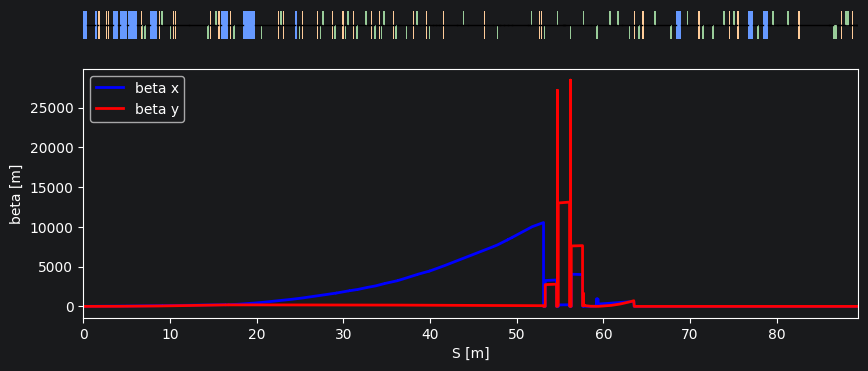

In [16]:
## Use drawBeamline in a plot
fig, axs = plt.subplots(2, 1, figsize=(10, 4), gridspec_kw = {'height_ratios': [1, 8]})

## Declare an instance of drawBeamline and apply it to our Lattice
drawer = drawBeamline(axs[0])
L.accept(drawer)

## Add the beta function plot
axs[0].set_xlim(0.0, L.get_length())
axs[1].plot(T[:,0], T[:,1], 'b-', linewidth=2, label='beta x')
axs[1].plot(T[:,0], T[:,2], 'r-', linewidth=2, label='beta y')
axs[1].legend(loc="upper left")
axs[1].set_xlabel('S [m]')
axs[1].set_ylabel('beta [m]')
axs[1].set_xlim(0.0, L.get_length())

plt.show()